In [87]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [192]:
df = pd.read_csv('/storage/group/pches/default/users/dcl5300/conus_comparison_lafferty-etal-2024/extreme_value/cities/original_grid/freq/denver_max_pr_1950-2100_mle_nonstat_nboot100_samples.csv')

In [193]:
df = (
    df
    .replace("canesm5", "CanESM5")
    .replace("cesm2", "CESM2-LENS")
    .replace("ecearth3", "EC-Earth3")
    .replace("1001_01", "r1i1p1f1")
    .replace("1021_02", "r2i1p1f1",)
    .replace("1041_03", "r3i1p1f1",)
    .replace("1061_04", "r4i1p1f1",)
    .replace("1081_05", "r5i1p1f1",)
    .replace("1101_06", "r6i1p1f1",)
    .replace("1121_07", "r7i1p1f1",)
    .replace("1141_08", "r8i1p1f1",)
    .replace("1161_09", "r9i1p1f1",)
    .replace("1181_10", "r10i1p1f1")
)

In [195]:
# aad based
calculate_df_uc(df, '100yr_return_level_diff_2075-1975', uc_type='aad').set_index('uncertainty_type')

,mean,std
uncertainty_type,,
ssp_uc,0.102518,0.109943
ssp_uc_by_gcm,0.377643,0.329398
gcm_uc,1.783690,0.419152
iv_uc,1.638182,0.572544
dsc_uc,0.825788,0.702003
fit_uc,8.067100,1.706799
fit_uc1,1.692956,0.343164
uc_99w_boot,19.957773,19.957773
uc_99w_main,15.159961,15.159961


In [196]:
# variance based
calculate_df_uc(df, '100yr_return_level_diff_2075-1975', uc_type='var').set_index('uncertainty_type')

,mean,std
uncertainty_type,,
ssp_uc,0.033013,0.045218
ssp_uc_by_gcm,0.424844,0.628195
gcm_uc,5.728314,2.408462
iv_uc,4.989585,3.057556
dsc_uc,2.331547,3.209873
fit_uc,8.067100,1.706799
fit_uc1,4.745257,2.055805
uc_99w_boot,19.957773,19.957773
uc_99w_main,15.159961,15.159961


In [203]:
d = [0.5,0.9]
np.max(d) - np.min(d)

0.4

In [208]:
np.quantile(d, 0.975) - np.quantile(d, 0.025)

0.38

In [198]:
# variance based
calculate_df_uc(df, '100yr_return_level_diff_2075-1975', uc_type='qrange').set_index('uncertainty_type')

,mean,std
uncertainty_type,,
ssp_uc,0.198576,0.203529
ssp_uc_by_gcm,0.910259,0.897710
gcm_uc,5.221869,1.415232
iv_uc,5.674060,1.935152
dsc_uc,1.568997,1.333806
fit_uc,8.067100,1.706799
fit_uc1,8.051318,1.702634
uc_99w_boot,19.957773,19.957773
uc_99w_main,15.159961,15.159961


In [199]:
# range based
calculate_df_uc(df, '100yr_return_level_diff_2075-1975', uc_type='range').set_index('uncertainty_type')

,mean,std
uncertainty_type,,
ssp_uc,0.209028,0.214241
ssp_uc_by_gcm,0.958168,0.944958
gcm_uc,5.535328,1.498168
iv_uc,6.315893,2.381830
dsc_uc,1.651575,1.404006
fit_uc,8.067100,1.706799
fit_uc1,10.826829,2.409751
uc_99w_boot,19.957773,19.957773
uc_99w_main,15.159961,15.159961


In [81]:
ds_idx = df_main.groupby(['gcm', 'member', 'ssp'], as_index=False).size().query('size >= 2').set_index(['gcm', 'member', 'ssp']).index

In [85]:
df_main = df.query('n_boot == "main"').reset_index()
ds_idx = df_main.groupby(['gcm', 'member', 'ssp'], as_index=False).size().query('size >= 2').set_index(['gcm', 'member', 'ssp']).index
df_plot = df_main.set_index(['gcm', 'member', 'ssp']).loc[ds_idx].reset_index()

In [95]:
n_min_members = 5
combos_to_include = (
        df_main.groupby(["ensemble", "gcm", "ssp"]).count()[plot_col] >= n_min_members
)

In [98]:
gcm_uc = (
        df_main.groupby(["ensemble", "gcm", "ssp"])[[plot_col]]
        .mean()
        .loc[combos_to_include]
)

In [134]:
iv_uc = (
        df_main.set_index(["ensemble", "gcm", "ssp"])[['member', plot_col]]
        .loc[combos_to_include]
    )

<Axes: xlabel='100yr_return_level_diff_2075-1975'>

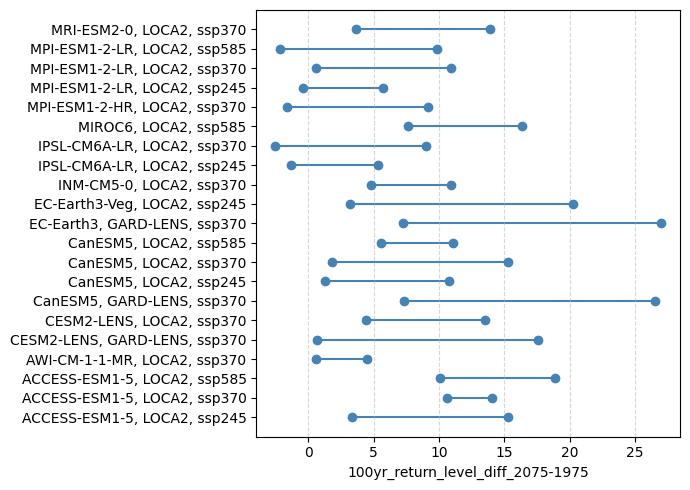

In [168]:
group_cols = ['gcm', 'ensemble', 'ssp']
plot_col = '100yr_return_level_diff_2075-1975'

dumbbell_plot(iv_uc.reset_index(), group_cols, plot_col, yheight=5)

<Axes: xlabel='100yr_return_level_diff_2075-1975'>

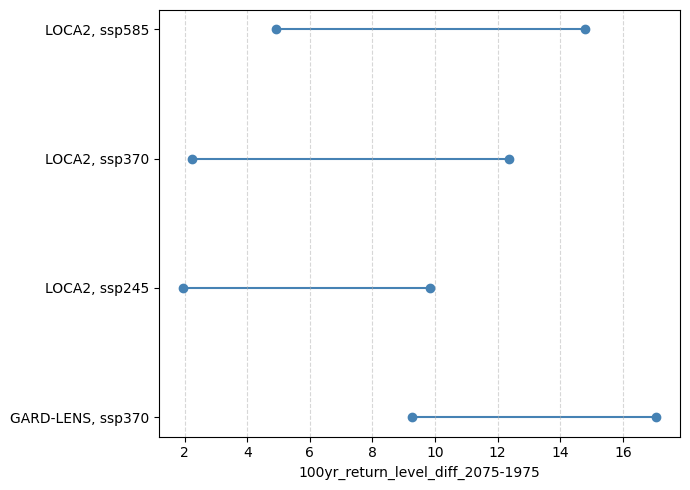

In [112]:
group_cols = ['ensemble', 'ssp']
plot_col = '100yr_return_level_diff_2075-1975'

dumbbell_plot(gcm_uc.reset_index(), group_cols, plot_col, yheight=5)

<Axes: xlabel='100yr_return_level_diff_2075-1975'>

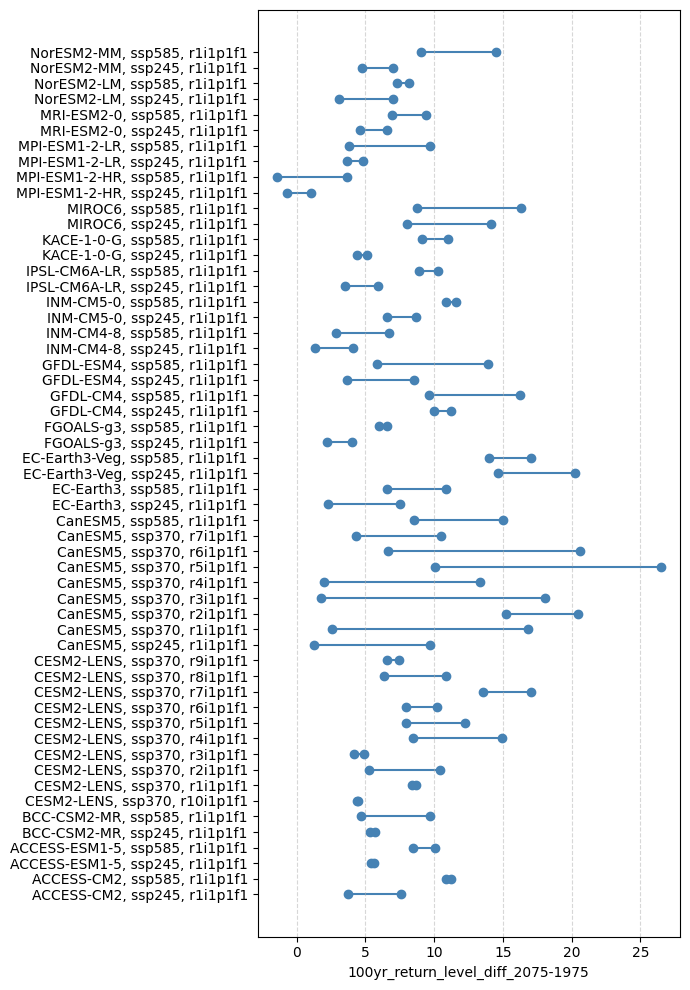

In [103]:
group_cols = ['gcm', 'ssp', 'member']
plot_col = '100yr_return_level_diff_2075-1975'

dumbbell_plot(df_plot, group_cols, plot_col)

In [111]:
def dumbbell_plot(df, group_cols, value_col, ax=None, yheight=10):
    """
    Parameters
    ----------
    df : pd.DataFrame
    group_cols : list of str
    value_col : str
    ax : matplotlib Axes, optional
    """
    grouped = df.groupby(group_cols)[value_col].apply(list).reset_index()
    grouped['label'] = grouped[group_cols].apply(lambda r: ', '.join(r.astype(str)), axis=1)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, yheight))

    for i, row in grouped.iterrows():
        x1, x2 = np.min(row[value_col]), np.max(row[value_col])
        ax.plot([x1, x2], [i, i], color='steelblue', linewidth=1.5, zorder=1)
        ax.scatter([x1, x2], [i, i], color='steelblue', zorder=2)

    ax.set_yticks(range(len(grouped)))
    ax.set_yticklabels(grouped['label'])
    ax.set_xlabel(value_col)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()

    return ax

In [197]:
def calculate_df_uc(df, plot_col, uc_type = 'range', n_min_members=5):
    """
    Calculate the uncertainty decomposition based on pd DataFrame.
    """

    # Just in case: drop TaiESM1 from STAR (too hot!)
    if "STAR-ESDM" in df["ensemble"].unique():
        df = df[df["member"] != "TaiESM1"]

    # Range functions
    if uc_type == 'range':
        def get_range(x):
            return x.max() - x.min()#/np.sqrt(len(x))
    elif uc_type == 'aad':
        def get_range(x):
            return np.mean(np.abs(x - x.mean()))
    elif uc_type == 'var':
        def get_range(x):
            return np.var(x, ddof=1)
    elif uc_type == 'qrange':
        def get_range(x):
            return np.quantile(x, 0.975) - np.quantile(x, 0.025)

    def get_quantile_range(df, groupby_cols, plot_col):
        df_tmp = pd.merge(
            df[df["quantile"] == "q975"].rename(
                columns={plot_col: f"{plot_col}_upper"}
            ),
            df[df["quantile"] == "q025"].rename(
                columns={plot_col: f"{plot_col}_lower"}
            ),
            on=groupby_cols,
        )

        df_tmp[f"{plot_col}_95range"] = (
            df_tmp[f"{plot_col}_upper"] - df_tmp[f"{plot_col}_lower"]
        )
        return df_tmp

    # Get combos to include
    if "n_boot" in df.columns:
        df_main = df[df["n_boot"] == "main"]
        df_boot = (
            df[df["n_boot"] != "main"]
            .groupby(["ensemble", "gcm", "member", "ssp"])
            .quantile([0.025, 0.975], numeric_only=True)
            .reset_index()
            .rename(columns={"level_4": "quantile"})
        )
        # Map quantiles to strings
        df_boot["quantile"] = df_boot["quantile"].map({0.025: "q025", 0.975: "q975"})
    elif "quantile" in df.columns:
        df_main = df[df["quantile"] == "main"]
        df_boot = df[df["quantile"] != "main"]
    else:
        df_main = df
        df_boot = None

    combos_to_include = (
        df_main.groupby(["ensemble", "gcm", "ssp"]).count()[plot_col] >= n_min_members
    )

    # Scenario uncertainty
    ssp_uc_by_gcm = (
        df_main.groupby(["ensemble", "gcm", "ssp"])[plot_col]
        .mean()
        .loc[combos_to_include]
        .groupby(["gcm", "ensemble"])
        .apply(get_range)
    )
    ssp_uc_by_gcm_mean = ssp_uc_by_gcm.replace(0.0, np.nan).mean()
    ssp_uc_by_gcm_std = ssp_uc_by_gcm.replace(0.0, np.nan).std()

    ssp_uc = (
        df_main.groupby(["ensemble", "ssp"])[plot_col]
        .mean()
        .groupby("ensemble")
        .apply(get_range)
    )
    ssp_uc_mean = ssp_uc.replace(0.0, np.nan).mean()
    ssp_uc_std = ssp_uc.replace(0.0, np.nan).std()

    # Response uncertainty
    gcm_uc = (
        df_main.groupby(["ensemble", "gcm", "ssp"])[plot_col]
        .mean()
        .loc[combos_to_include]
        .groupby(["ssp", "ensemble"])
        .apply(get_range)
    )
    gcm_uc_mean = gcm_uc.replace(0.0, np.nan).mean()
    gcm_uc_std = gcm_uc.replace(0.0, np.nan).std()

    # Internal variability
    iv_uc = (
        df_main.groupby(["ensemble", "gcm", "ssp"])[plot_col]
        .apply(get_range)
        .loc[combos_to_include]
    )
    iv_uc_mean = iv_uc.replace(0.0, np.nan).mean()
    iv_uc_std = iv_uc.replace(0.0, np.nan).std()

    # Downscaling uncertainty
    ds_uc = df_main.groupby(["gcm", "ssp", "member"])[plot_col].apply(get_range)
    ds_uc_mean = ds_uc.replace(0.0, np.nan).mean()
    ds_uc_std = ds_uc.replace(0.0, np.nan).std()

    # Total uncertainty
    if "n_boot" in df.columns:
        df_samples = df[df["n_boot"] != "main"]
        uc_99w_boot = df_samples[plot_col].quantile(0.995) - df_samples[
            plot_col
        ].quantile(0.005)
        uc_99w_main = df_main[plot_col].quantile(0.995) - df_main[plot_col].quantile(
            0.005
        )
    elif "quantile" in df.columns:
        upper = df[df["quantile"] == "q975"][plot_col].quantile(0.995)
        lower = df[df["quantile"] == "q025"][plot_col].quantile(0.005)
        uc_99w_boot = upper - lower
        uc_99w_main = df_main[plot_col].quantile(0.995) - df_main[plot_col].quantile(
            0.005
        )
    else:
        uc_99w_main = df[plot_col].quantile(0.995) - df[plot_col].quantile(0.005)
        uc_99w_boot = np.nan

    # Fit uncertainty if included
    fit_uc = get_quantile_range(
        df=df_boot,
        groupby_cols=["gcm", "ensemble", "member", "ssp"],
        plot_col=plot_col,
    )
    fit_uc_mean = fit_uc[f"{plot_col}_95range"].mean()
    fit_uc_std = fit_uc[f"{plot_col}_95range"].std()

    fit_uc1 = df.groupby(["ensemble", "gcm", "ssp", "member"])[plot_col].apply(get_range)
    fit_uc1_mean = fit_uc1.mean()
    fit_uc1_std = fit_uc1.std()

    # Return all
    return pd.DataFrame(
        {
            "uncertainty_type": [
                "ssp_uc",
                "ssp_uc_by_gcm",
                "gcm_uc",
                "iv_uc",
                "dsc_uc",
                "fit_uc",
                "fit_uc1",
                "uc_99w_boot",
                "uc_99w_main",
            ],
            "mean": [
                ssp_uc_mean,
                ssp_uc_by_gcm_mean,
                gcm_uc_mean,
                iv_uc_mean,
                ds_uc_mean,
                fit_uc_mean,
                fit_uc1_mean,
                uc_99w_boot,
                uc_99w_main,
            ],
            "std": [
                ssp_uc_std,
                ssp_uc_by_gcm_std,
                gcm_uc_std,
                iv_uc_std,
                ds_uc_std,
                fit_uc_std,
                fit_uc1_std,
                uc_99w_boot,
                uc_99w_main,
            ],
        }
    )